# Now modus operandi here would be:
1. Train test split
2. Scaling the footfall using log_transformer,RP and temparature using standardScaler in the meantime the rest of variable will be encoded with one-hot encoding

# First lets selecting the input and output features first

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [25]:
data  = pd.read_csv(r"C:\Users\Public\My projects\notebook\data.csv")
df = data.copy()

In [26]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

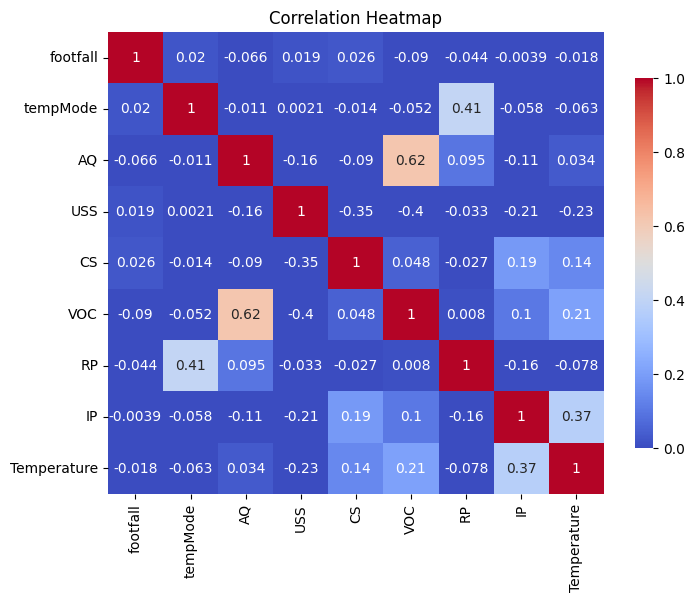

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(
    X.corr(), annot=True, cmap="coolwarm",
            cbar_kws={"shrink": .8},
            vmin=0,
              vmax=1
            )
plt.title("Correlation Heatmap")
plt.savefig("Correlation Heatmap.png")
plt.show()

# Now splitting the data for training and testing

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Now scaling the values and also I will do some encoding

In [29]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

log_features = ["footfall"]
standard_features = ["Temperature"]
categorical_features = [col for col in X.columns if col not in log_features + standard_features]

# Transformers
log_transformer = Pipeline(steps=[
    ("log", FunctionTransformer(np.log1p))  # log(1+x) to handle zero values
])

standard_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

ohe_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ColumnTransformer combining all
preprocessor = ColumnTransformer(transformers=[
    ("log",      log_transformer,      log_features),
    ("standard", standard_transformer, standard_features),
    ("ohe",      ohe_transformer,      categorical_features)
])

# Fit and transform on training data only, transform test data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

print("X_train shape after preprocessing:", X_train_transformed.shape)
print("X_test shape after preprocessing: ", X_test_transformed.shape)


X_train shape after preprocessing: (660, 116)
X_test shape after preprocessing:  (284, 116)


In [30]:
X_train_transformed

array([[ 5.14166356,  0.11968038,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 2.99573227, -0.21501899,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 8.8957666 ,  0.11968038,  1.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 3.17805383,  1.12377849,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 4.7095302 ,  0.11968038,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 4.44265126, -1.55381647,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [31]:
import joblib
import os

# Save the preprocessing pipeline
save_path = r"C:\Users\Public\My projects\notebook\preprocessor.pkl"
joblib.dump(preprocessor, save_path)
print(f"Preprocessor saved to: {save_path}")


Preprocessor saved to: C:\Users\Public\My projects\notebook\preprocessor.pkl
